Here we will train and optimize Graph Neural Networks (GNN) on the PDBind dataset. We will use data where affinities are evaluated in Kd vallues for couples of molecules and proteins, specifically those of the bigger group of the data set that represent a thousand couples of molecules with hydrolases. In order to have a better distribution of the kd values, we convert them in nM and compute their logarithm value.  

In [ ]:
import pandas as pd
from scripts.preprocessing import PDBpreprocessing

raw_data = pd.read_csv("data/LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= 'Hydrolase', variable='both', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

ModuleNotFoundError: No module named 'code.preprocessing'; 'code' is not a package

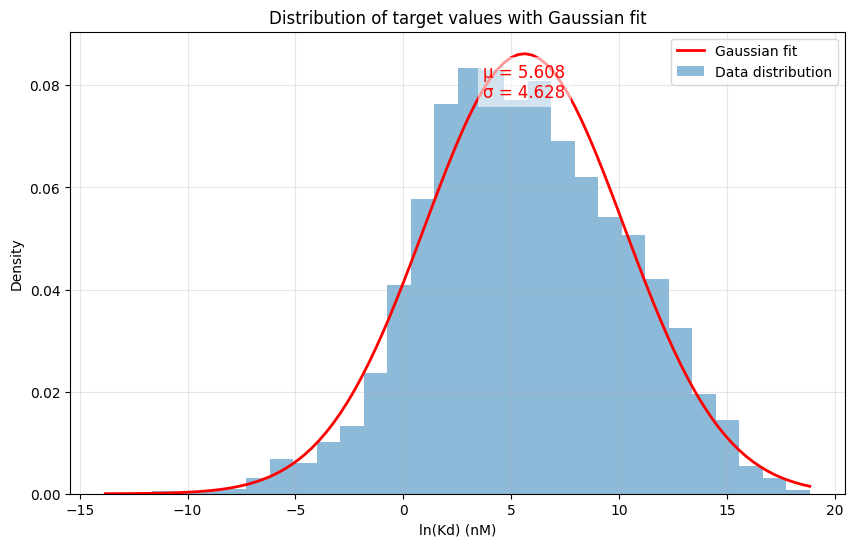

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Extract data
data = preprocessed_data['target'].dropna().values

# Compute stats
mean = np.mean(data)
std = np.std(data)

# Histogram setup
X_plot = np.linspace(data.min(), data.max(), 100)
Y_hist, bin_edges = np.histogram(data, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Gaussian (normal) fit
Y_gauss = norm.pdf(X_plot, mean, std)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, Y_hist, width=np.diff(bin_edges), alpha=0.5, label='Data distribution')
plt.plot(X_plot, Y_gauss, 'r-', linewidth=2, label='Gaussian fit')

# Add text for mean and std
plt.text(mean, max(Y_gauss)*0.9, f"μ = {mean:.3f}\nσ = {std:.3f}", 
         fontsize=12, color='red', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel('ln(Kd) (nM)')
plt.ylabel('Density')
plt.title('Distribution of target values with Gaussian fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# ===============================================
# GNN Regression on preprocessed_data (SMILES + target)
# ===============================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, InMemoryDataset, DataLoader
from ogb.utils import smiles2graph
from rdkit import Chem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

# ------------------------------
# Config
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_dim = 64
batch_size = 64
epochs = 500
lr = 0.5e-3

# ===============================================
# Step 1 — Build dataset from preprocessed_data
# ===============================================

preprocessed_data = preprocessed_data[preprocessed_data['smiles'].apply(lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)].reset_index(drop=True)

class InMemorySMILESDataset(InMemoryDataset):
    def __init__(self, df, transform=None, pre_transform=None):
        self.df = df.reset_index(drop=True)
        super().__init__(None, transform, pre_transform)
        self.data, self.slices = self.process_df()

    def process_df(self):
        data_list = []
        for smiles, y in tqdm(zip(self.df["smiles"], self.df["target"]), total=len(self.df), desc="Converting SMILES"):
            graph = smiles2graph(smiles)
            x = torch.tensor(graph["node_feat"], dtype=torch.float)
            edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
            edge_attr = torch.tensor(graph["edge_feat"], dtype=torch.float)
            y = torch.tensor([y], dtype=torch.float)
            data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))
        return self.collate(data_list)

# Create dataset directly from your DataFrame
dataset = InMemorySMILESDataset(preprocessed_data)
print(f"✅ Dataset built: {len(dataset)} molecules")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

# ===============================================
# Step 2 — Train / Val / Test Split
# ===============================================
num_graphs = len(dataset)
train_len = int(0.8 * num_graphs)
val_len = int(0.1 * num_graphs)
test_len = num_graphs - train_len - val_len

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ===============================================
# Step 3 — Model Definition (OGB-style)
# ===============================================
class GCNRegression(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim=1):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)

# Initialize model
model = GCNRegression(dataset[0].x.shape[1], hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

# ===============================================
# Step 4 — Training Loop
# ===============================================
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss += loss_fn(out, batch.y.view(-1)).item() * batch.num_graphs
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ===============================================
# Step 5 — Evaluation on Test Set
# ===============================================
model.eval()
ys, preds = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        ys.append(batch.y.view(-1).cpu().numpy())
        preds.append(out.cpu().numpy())

ys = np.concatenate(ys)
preds = np.concatenate(preds)

mse = mean_squared_error(ys, preds)
r2 = r2_score(ys, preds)
print(f"\nTest MSE: {mse:.4f} | R²: {r2:.4f}")

# ===============================================
# Step 6 — Visualization
# ===============================================
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train", marker="o")
plt.plot(val_losses, label="Validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curves (GNN Regression)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Scatter plot of predictions
plt.figure(figsize=(6, 6))
plt.scatter(ys, preds, alpha=0.6)
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()], "r--")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True")
plt.show()


[11:52:11] Unusual charge on atom 1 number of radical electrons set to zero
[11:52:11] Unusual charge on atom 12 number of radical electrons set to zero
[11:52:11] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[11:52:11] Unusual charge on atom 13 number of radical electrons set to zero
[11:52:12] Unusual charge on atom 15 number of radical electrons set to zero
[11:52:12] Explicit valence for atom # 6 Br, 3, is greater than permitted
Converting SMILES: 100%|██████████| 5735/5735 [00:07<00:00, 751.43it/s]
c:\Users\33695\Documents\GitHub\cheminfo_project\.venv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


✅ Dataset built: 5735 molecules
Node feature dim: 9
Epoch 001 | Train Loss: 36.6144 | Val Loss: 21.4244
Epoch 002 | Train Loss: 21.5318 | Val Loss: 21.2332
Epoch 003 | Train Loss: 21.4542 | Val Loss: 21.1998
Epoch 004 | Train Loss: 21.4354 | Val Loss: 21.1745
Epoch 005 | Train Loss: 21.4232 | Val Loss: 21.1524
Epoch 006 | Train Loss: 21.3854 | Val Loss: 21.1390
Epoch 007 | Train Loss: 21.3664 | Val Loss: 21.1203
Epoch 008 | Train Loss: 21.3331 | Val Loss: 21.1295
Epoch 009 | Train Loss: 21.3140 | Val Loss: 21.2140
Epoch 010 | Train Loss: 21.2738 | Val Loss: 21.0774
Epoch 011 | Train Loss: 21.2277 | Val Loss: 21.1000
Epoch 012 | Train Loss: 21.2235 | Val Loss: 21.2035
Epoch 013 | Train Loss: 21.2422 | Val Loss: 21.1841
Epoch 014 | Train Loss: 21.1991 | Val Loss: 21.0744
Epoch 015 | Train Loss: 21.1859 | Val Loss: 21.0597
Epoch 016 | Train Loss: 21.1558 | Val Loss: 21.1104
Epoch 017 | Train Loss: 21.1194 | Val Loss: 21.0252
Epoch 018 | Train Loss: 21.1034 | Val Loss: 21.0880
Epoch 019 | 

+ Learning curve test/validation before optimization